In [59]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


np.random.seed(42)

In [60]:
# DATA
tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]
n_sims = 10_000
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
conf_lvl = 0.05 # confidence level = 95%

prices = yf.download(tickers, start = "2020-01-01" , auto_adjust = True)
prices = prices["Close"].dropna()
returns  = prices.pct_change().dropna()
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,605.529358,519.138000,633.151123,675.324158,1866.113892
2020-01-02,609.389099,522.861572,631.303711,686.821228,1857.547485
2020-01-03,600.698792,521.169006,641.013306,687.648804,1894.566406
2020-01-06,587.698730,508.450531,634.869629,671.700684,1894.395020
2020-01-07,597.004822,505.742401,625.460693,682.034607,1899.043823


In [68]:
# Assigning weights based on the total market cap of the respective company

# Fetch the live Market Cap for each ticker
mcaps = []
for ticker in tickers:
    stock_info = yf.Ticker(ticker)

    mcap = stock_info.info.get('marketCap', 0) 
    mcaps.append(mcap)
mcaps = np.array(mcaps)

# Calculating the weights
weights = mcaps / np.sum(mcaps)

print("--- LIVE MARKET CAP WEIGHTS ---")
for t, w in zip(tickers, weights):
    print(f"{t}: {w*100:.2f}%")
print("Sum of weights: ",weights.sum())

--- LIVE MARKET CAP WEIGHTS ---
RELIANCE.NS: 34.70%
TCS.NS: 16.83%
HDFCBANK.NS: 21.95%
INFY.NS: 9.99%
ICICIBANK.NS: 16.53%
Sum of weights:  1.0


In [62]:
#parameters

mu    = returns.mean().values           # daily mean returns
sigma = returns.std().values            # daily volatilities
corr  = returns.corr().values           # correlation matrix

In [ ]:
# CHOLESKY DECOMPOSITION
# Decompose correlation matrix so simulated returns are correlated
L = np.linalg.cholesky(corr)

# MONTE CARLO SIMULATION
Z         = np.random.standard_normal((n_sims, len(tickers)))
Z_corr    = Z @ L.T                                  # inject correlation
sim_returns = mu + sigma * Z_corr                    # scale by vol + drift

In [64]:
# Portfolio

portfolio_returns = sim_returns @ weights

# VaR(Value at Risk) and CVaR(Conditional VaR)

VaR = np.percentile(portfolio_returns, conf_lvl*100)

worst_days = portfolio_returns[portfolio_returns < VaR]
CVaR = np.mean(worst_days)

print(f"95% VaR: {VaR:.4%}")
print(f"95% CVaR: {CVaR:.4%}")

# Historical Values for Comparision

hist_portfolio = returns @ weights
hist_VaR  = np.percentile(hist_portfolio, conf_lvl * 100)
hist_CVaR = hist_portfolio[hist_portfolio <= hist_VaR].mean()

print(f"95% Historical VaR: {hist_VaR:.4%}")
print(f"95% Historical CVaR: {hist_CVaR:.4%}")


95% VaR: -2.0440%
95% CVaR: -2.6038%
95% Historical VaR: -1.6929%
95% Historical CVaR: -2.9421%


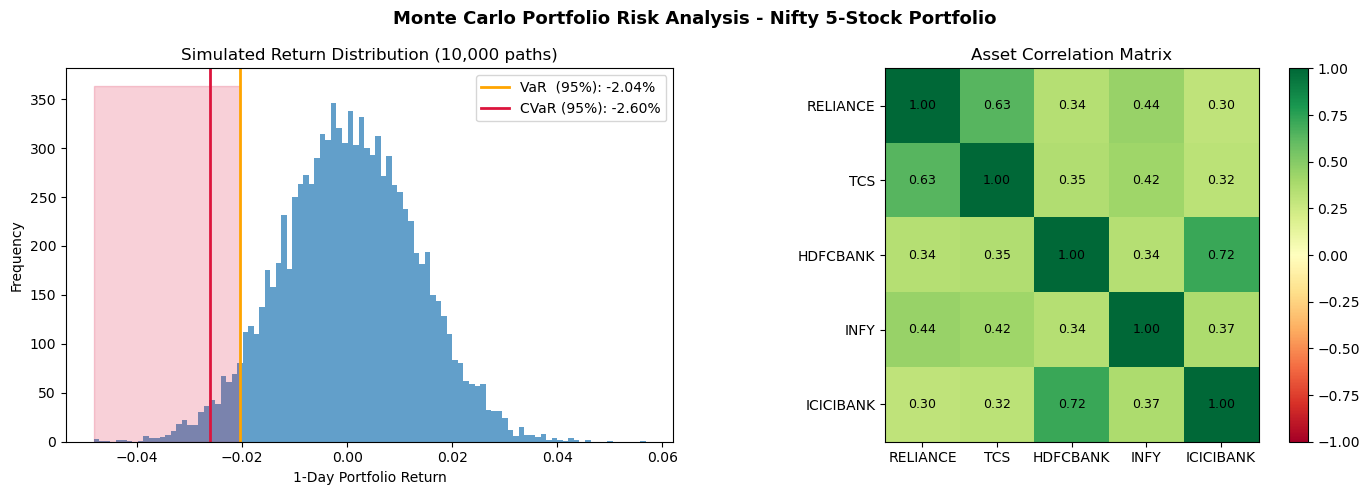

In [65]:
# Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Monte Carlo Portfolio Risk Analysis - Nifty 5-Stock Portfolio", fontsize=13, fontweight="bold")

# Plot 1: MC return distribution with VaR/CVaR marked
ax = axes[0]
ax.hist(portfolio_returns, bins=100, alpha=0.7)
ax.axvline(VaR,  color="orange", linewidth=2, label=f"VaR  (95%): {VaR:.2%}")
ax.axvline(CVaR, color="crimson", linewidth=2, label=f"CVaR (95%): {CVaR:.2%}")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 500], portfolio_returns.min(), VaR, alpha=0.2, color="crimson")
ax.set_xlabel("1-Day Portfolio Return")
ax.set_ylabel("Frequency")
ax.set_title("Simulated Return Distribution (10,000 paths)")
ax.legend()

# Plot 2: Correlation heatmap
ax2 = axes[1]
im = ax2.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax2)
labels = [t.replace(".NS", "") for t in tickers]
ax2.set_xticks(range(len(labels))); ax2.set_xticklabels(labels)
ax2.set_yticks(range(len(labels))); ax2.set_yticklabels(labels)
ax2.set_title("Asset Correlation Matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax2.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("risk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()